In [1]:
from pathlib import Path
import sys
import numpy as np
from CoolProp.HumidAirProp import HAPropsSI
from CoolProp.CoolProp import PropsSI
sys.path.insert(0, str(Path.cwd().parent))
from Framework.core.config import CaseConfig, GridShape
from Framework.core.geometry import FinnTubedHX
from Framework.models import Frostmodell_V1
from Framework.runtime.simulator import Simulator
from Framework.visualisation import plot
from Framework.visualisation.read_from_csv import read_results_csv_json

# Case Definieren

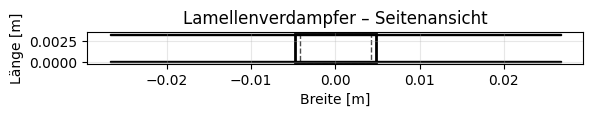

In [2]:
sim_run = True
save_data = False
read_data = False

T_a = 2.0
P = 101325
RH = 0.85
v_a = 1.2

w_amb_in = HAPropsSI('W','T',T_a+273.15,'P',P,'R', RH)
rho_amb_in = 1.0 / HAPropsSI("Vha","T",T_a+273.15,"P",P,"R",RH)

refrigerant = "R134a"
x_in = 0.4
T_ref_in = -10.0
p_ref_in = PropsSI("P", "T", T_ref_in + 273.15, "Q", x_in, refrigerant)
h_ref_in = PropsSI("H", "T", T_ref_in + 273.15, "Q", x_in, refrigerant)

geom = FinnTubedHX(
    n_seg_l = 5,        # -
    n_seg_r = 5,        # -
    n_fin = 2,           # -
    l_fin = 0.022,          # m
    h_fin = 0.022,          # m
    fin_thickness = 0.0002,    # m
    fin_pitch = 0.0032,          # m
    d_tube_a = 0.00952,          # m
    tube_thickness = 0.0005,       # m
    lambda_fin = 237,            # W/mK
    rho_solid = 2700,            # kg/m3
    c_solid = 900,               # J/kgK
    CP = "row_serpentine"
)

gs = GridShape(
    t_end = 60.0*10.0,      # s endtime
    dt = 1.0,           # s time step
    store_grid_every_x_it = 10,

    nx = 100,
    nr = 100,
    ntheta = 90
)

cfg = CaseConfig(
    # air data
    m_dot = v_a*rho_amb_in*(geom.h_fin*geom.l_tube()*geom.n_seg_r),
    T_a = T_a,          # °C temperature air
    v_a = v_a,          # m/s velocity air
    p_a = P,            # Pa pressure air
    RH = RH,            # relative humidity air
    w_amb = w_amb_in,          # kg/kg water vapor moisture content
    rho_amb = rho_amb_in,      # kg/m^3 density air
    v_kin = 1.5e-5,     # m^2/s kinematic viscosity air
    lam = 0.025,        # W/mK heat conduction coefficient air
    c_p_a = 1000,       # J/kgK heat capacity air
    D_std = 2.2e-5,     # m^2/s water vapor diffusion coefficient
    C = 900,            # 1/s empirical water vapor absorbed coefficient
    isv = 2830000,      # J/kg latent heat of desublimation

    # refrigerant data
    ref_str = refrigerant,
    T_tube = T_ref_in,    # °C tube temperature
    T_ref = T_ref_in,     # °C tube temperature
    p_ref = p_ref_in,      # Pa Kältemitteldruck
    h_ref = h_ref_in,          # J/mol spezifische Enthalpie
    V_dot_ref = 1e-4,      # m^3/s Volumenstrom
    x_ref = x_in,           # Dampfqualität (0..1), NaN falls einphasig

    # ice data
    rho_i = 920,        # kg/m^3 ice density
    h_sub= 2830000,     # J/kg latent heat of ablimation for water vapor
)

plot.plot_finned_tube_side(geom)

# Simulation laufen lassen

In [3]:
if sim_run:
    sim = Simulator(geom,cfg)
    results = sim.run(cfg, geom, gs, Frostmodell_V1)

Time Step: 1	 Time: 0.0 s | 0.0 min
Segment [0,0]
Edge Domain Inner Iterations: 73 	 	 	 w: 1.588e-11 	 T: 9.996e-07 	 cycle time: 0.286 s
Finn & Tube Domain Inner Iterations: 138 	 w: 1.702e-11 	 T: 9.338e-07 	 cycle time: 0.524 s
Updating the air state for this segment [0,0]...
Coolprop raised an exception when calculating RH_out, overwriting with RH_out = 0.850.
Air Domain Results:  	 new T: -3.09 °C 	 new w: 3.098e-03 kg/kg 	 new P: 1.013e+05 Pa
Segment [0,1]
Edge Domain Inner Iterations: 73 	 	 	 w: 1.588e-11 	 T: 9.996e-07 	 cycle time: 0.290 s
Finn & Tube Domain Inner Iterations: 138 	 w: 1.702e-11 	 T: 9.338e-07 	 cycle time: 0.525 s
Updating the air state for this segment [0,1]...
Coolprop raised an exception when calculating RH_out, overwriting with RH_out = 0.850.
Air Domain Results:  	 new T: -3.09 °C 	 new w: 3.098e-03 kg/kg 	 new P: 1.013e+05 Pa
Segment [0,2]
Edge Domain Inner Iterations: 73 	 	 	 w: 1.588e-11 	 T: 9.996e-07 	 cycle time: 0.288 s
Finn & Tube Domain Inner 

# Resultate speichen/laden

In [4]:
result_file = "results_test.csv"

if sim_run:
    data = results.data

if save_data and sim_run:
    results.to_csv(result_file,data)

if read_data:
    data = read_results_csv_json(result_file)

# Resultate plotten

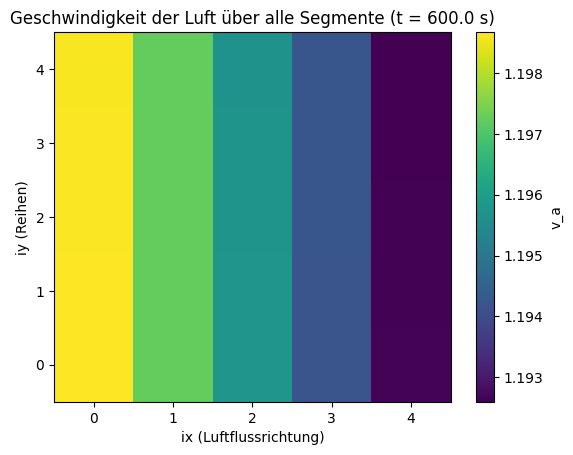

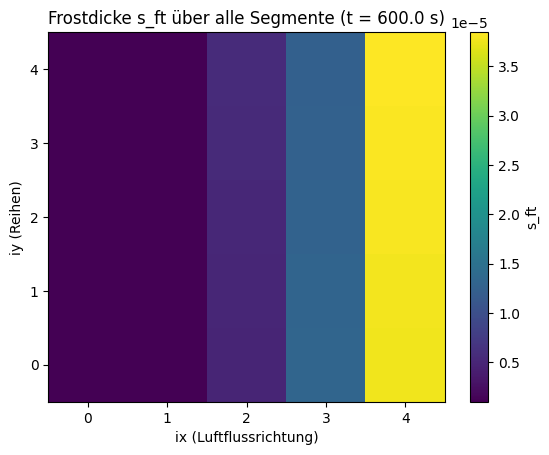

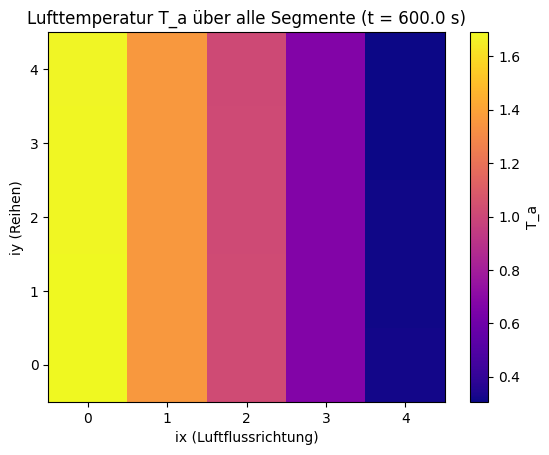

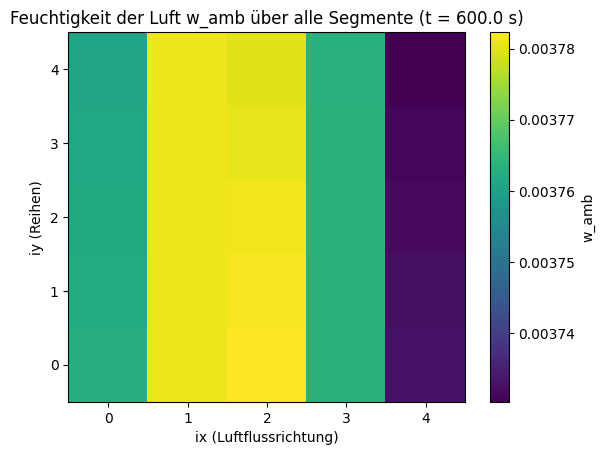

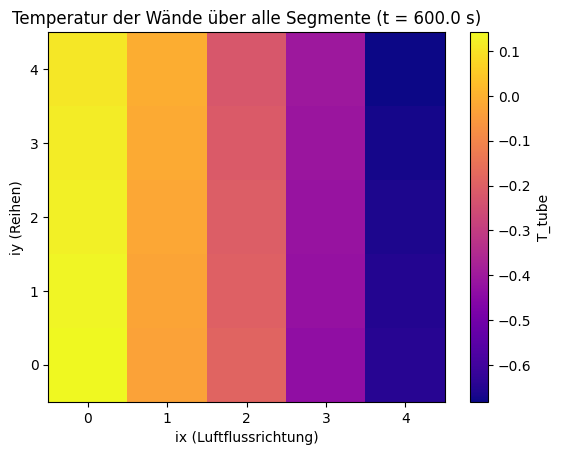

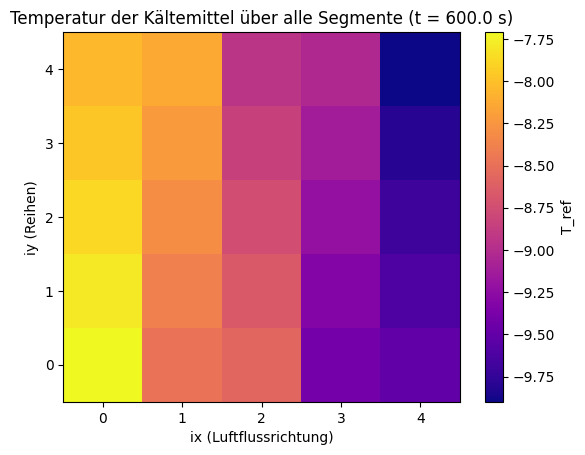

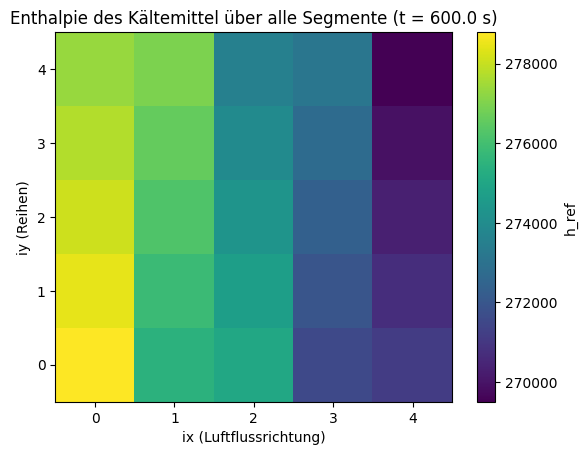

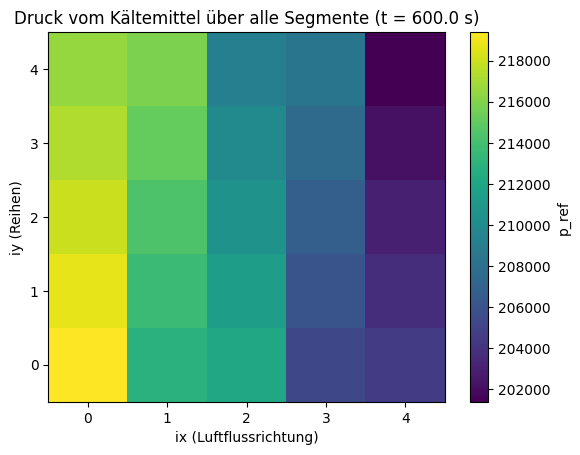

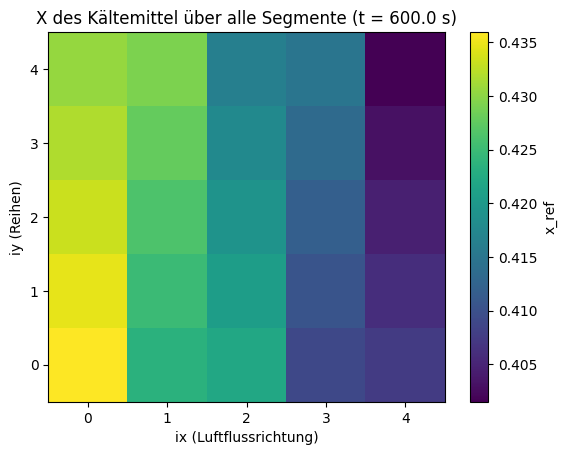

In [5]:
snapshots = results.grid_snapshots

fig, ax, Z_sft = plot.plot_segment_field_grid(
    snapshots,
    field="v_a",
    source="cfg",
    t_idx=-1,          # letzter Zeitschritt
    title="Geschwindigkeit der Luft über alle Segmente",
    cmap="viridis"
)

fig, ax, Z_sft = plot.plot_segment_field_grid(
    snapshots,
    field="s_ft",
    source="st",       # aus SimState
    t_idx=-1,          # letzter Zeitschritt
    title="Frostdicke s_ft über alle Segmente",
    cmap="viridis"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="T_a",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Lufttemperatur T_a über alle Segmente",
    cmap="plasma"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="w_amb",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Feuchtigkeit der Luft w_amb über alle Segmente",
    cmap="viridis"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="T_tube",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Temperatur der Wände über alle Segmente",
    cmap="plasma"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="T_ref",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Temperatur der Kältemittel über alle Segmente",
    cmap="plasma"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="h_ref",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Enthalpie des Kältemittel über alle Segmente",
    cmap="viridis"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="p_ref",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="Druck vom Kältemittel über alle Segmente",
    cmap="viridis"
)

fig, ax, Z_Ta = plot.plot_segment_field_grid(
    snapshots,
    field="x_ref",
    source="cfg",      # aus CaseConfig
    t_idx=-1,
    title="X des Kältemittel über alle Segmente",
    cmap="viridis"
)

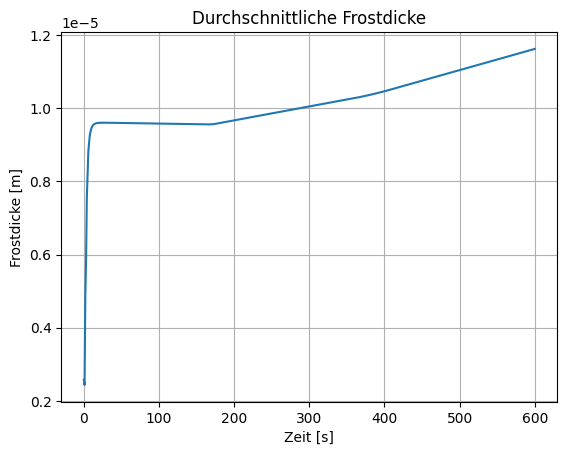

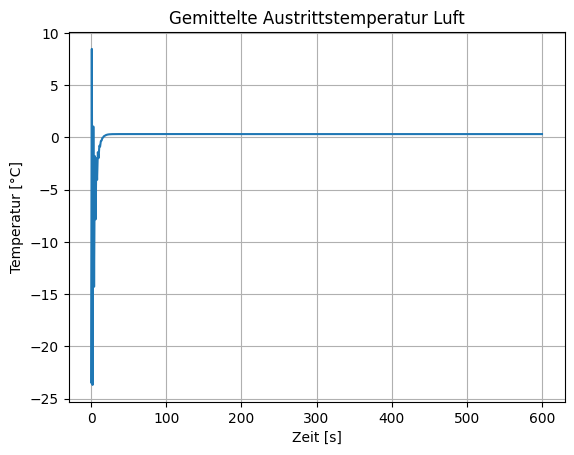

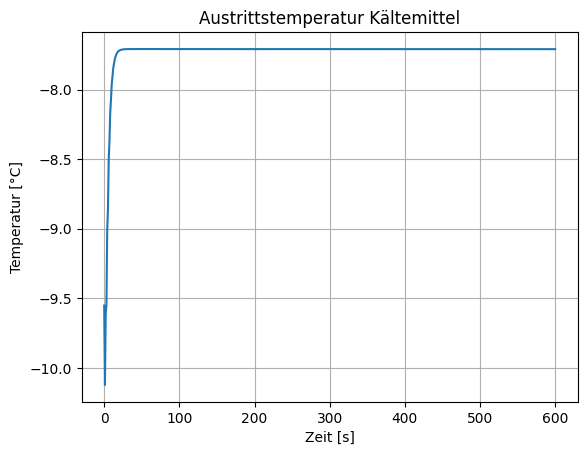

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Austrittstemperatur Kältemittel'}, xlabel='Zeit [s]', ylabel='Temperatur [°C]'>)

In [6]:
plot.plot_any(kind="time vs any",
              x=data['t'], y=data['mean_s_ft'],
              xlabel="Zeit [s]", ylabel="Frostdicke [m]",
              title=f"Durchschnittliche Frostdicke", marker=None)

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['T_out_air_mean'],
              xlabel="Zeit [s]", ylabel="Temperatur [°C]",
              title=f"Gemittelte Austrittstemperatur Luft", marker=None)

plot.plot_any(kind="time vs any",
              x=data['t'], y=data['T_out_ref'],
              xlabel="Zeit [s]", ylabel="Temperatur [°C]",
              title=f"Austrittstemperatur Kältemittel", marker=None)

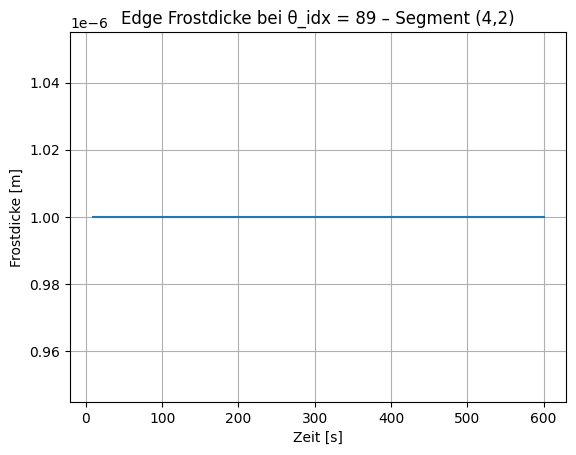

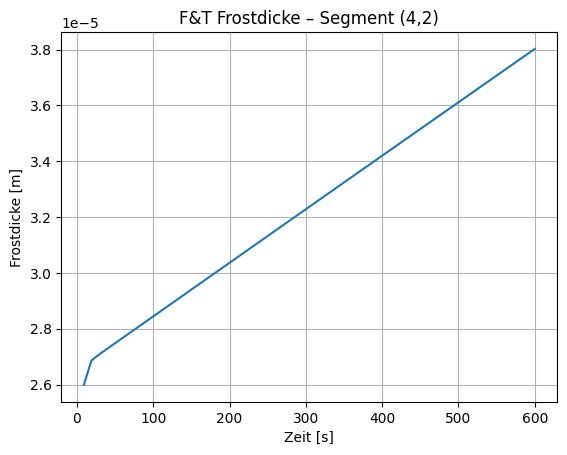

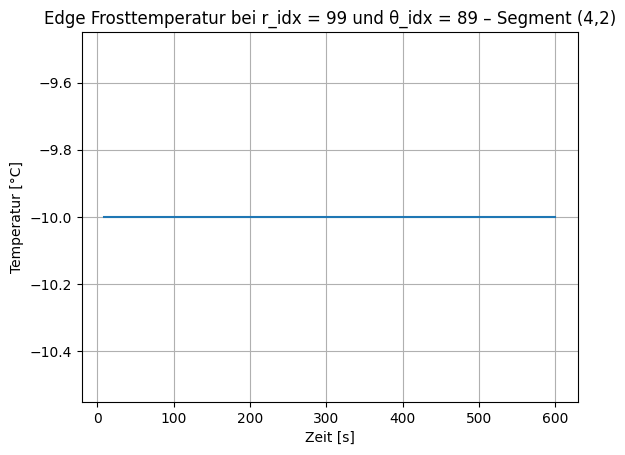

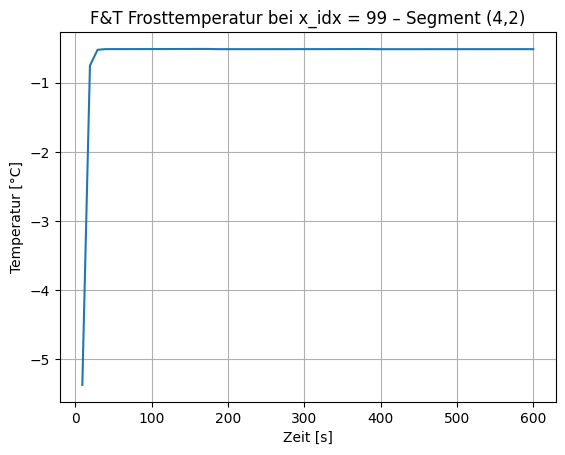

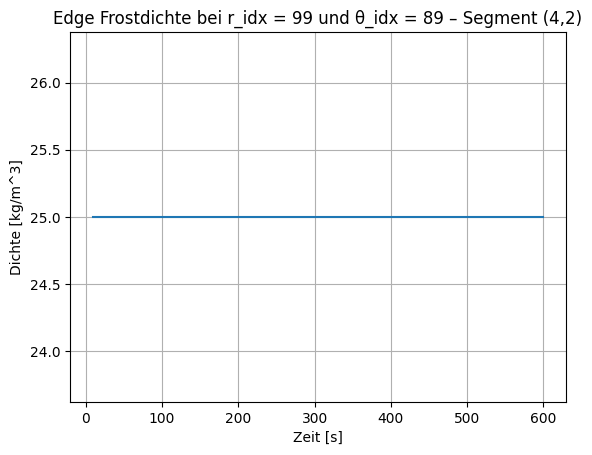

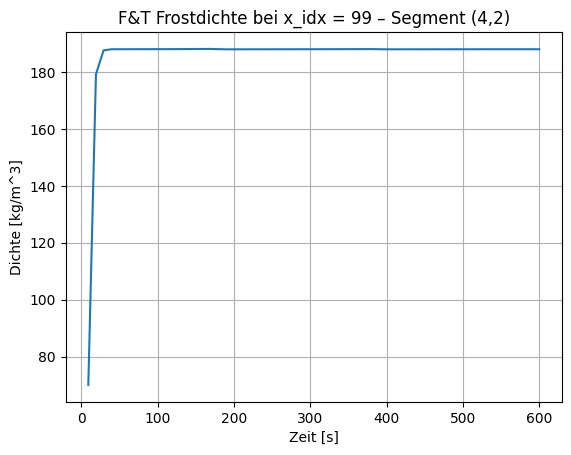

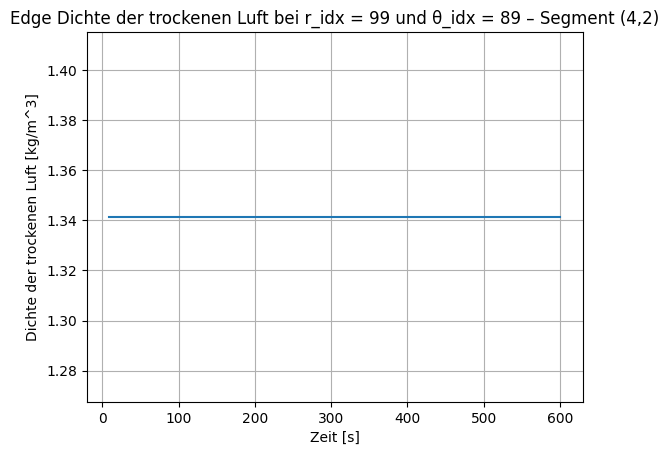

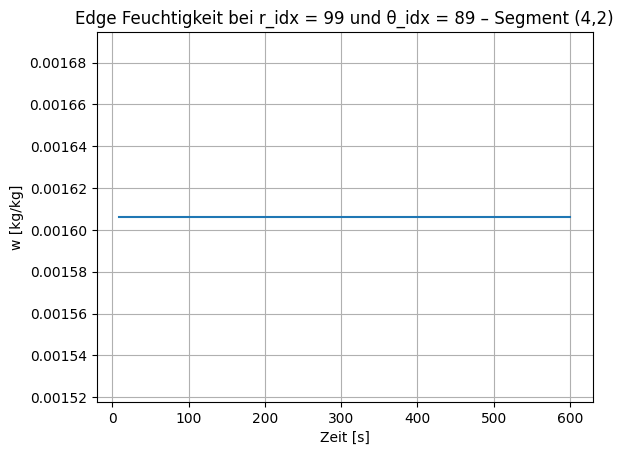

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Edge Feuchtigkeit bei r_idx = 99 und θ_idx = 89 – Segment (4,2)'}, xlabel='Zeit [s]', ylabel='w [kg/kg]'>)

In [7]:
# Segment auswählen
ix, iy = 4, 2

plot_r = int(gs.nr-1)
plot_x = int(gs.nx-1)
plot_theta = int(gs.ntheta-1)
plot_time = int(max(data['t'])/gs.dt)

t, s_e = plot.extract_segment_timeseries_from_snapshots(snapshots, "s_e", ix, iy)
plot.plot_any(kind="time vs 1D(theta)",
              x=t, y=s_e,
              xlabel="Zeit [s]", ylabel="Frostdicke [m]",
              title=f"Edge Frostdicke bei θ_idx = {plot_theta} – Segment ({ix},{iy})",
              theta_idx=plot_theta, marker=None)
t, s_ft = plot.extract_segment_timeseries_from_snapshots(snapshots, "s_ft", ix, iy)
plot.plot_any(kind="time vs any",
              x=t, y=s_ft,
              xlabel="Zeit [s]", ylabel="Frostdicke [m]",
              title=f"F&T Frostdicke – Segment ({ix},{iy})", marker=None)
t, T_e = plot.extract_segment_timeseries_from_snapshots(snapshots, "T_e", ix, iy)
plot.plot_any(kind="time vs 2D(r,theta)",
              x=t, y=T_e,
              xlabel="Zeit [s]", ylabel="Temperatur [°C]",
              title=f"Edge Frosttemperatur bei r_idx = {plot_r} und θ_idx = {plot_theta} – Segment ({ix},{iy})",
              r_idx=plot_r, theta_idx=plot_theta, marker=None)
t, T_ft = plot.extract_segment_timeseries_from_snapshots(snapshots, "T_ft", ix, iy)
plot.plot_any(kind="time vs 1D(r)",
              x=t, y=T_ft,
              xlabel="Zeit [s]", ylabel="Temperatur [°C]",
              title=f"F&T Frosttemperatur bei x_idx = {plot_x} – Segment ({ix},{iy})",
              r_idx=plot_x, marker=None)
t, rho_e = plot.extract_segment_timeseries_from_snapshots(snapshots, "rho_e", ix, iy)
plot.plot_any(kind="time vs 2D(r,theta)",
              x=t, y=rho_e,
              xlabel="Zeit [s]", ylabel="Dichte [kg/m^3]",
              title=f"Edge Frostdichte bei r_idx = {plot_r} und θ_idx = {plot_theta} – Segment ({ix},{iy})",
              r_idx=plot_r, theta_idx=plot_theta, marker=None)
t, rho_ft = plot.extract_segment_timeseries_from_snapshots(snapshots, "rho_ft", ix, iy)
plot.plot_any(kind="time vs 1D(r)",
              x=t, y=rho_ft,
              xlabel="Zeit [s]", ylabel="Dichte [kg/m^3]",
              title=f"F&T Frostdichte bei x_idx = {plot_x} – Segment ({ix},{iy})",
              r_idx=plot_x, marker=None)
t, rho_a_e = plot.extract_segment_timeseries_from_snapshots(snapshots, "rho_a_e", ix, iy)
plot.plot_any(kind="time vs 2D(r,theta)",
              x=t, y=rho_a_e,
              xlabel="Zeit [s]", ylabel="Dichte der trockenen Luft [kg/m^3]",
              title=f"Edge Dichte der trockenen Luft bei r_idx = {plot_r} und θ_idx = {plot_theta} – Segment ({ix},{iy})",
              r_idx=plot_r, theta_idx=plot_theta, marker=None)
t, w_e = plot.extract_segment_timeseries_from_snapshots(snapshots, "w_e", ix, iy)
plot.plot_any(kind="time vs 2D(r,theta)",
              x=t, y=w_e,
              xlabel="Zeit [s]", ylabel="w [kg/kg]",
              title=f"Edge Feuchtigkeit bei r_idx = {plot_r} und θ_idx = {plot_theta} – Segment ({ix},{iy})",
              r_idx=plot_r, theta_idx=plot_theta, marker=None)

In [8]:

_, T_e      = plot.extract_segment_timeseries_from_snapshots(snapshots, "T_e",      ix, iy)
plot.plot_spatial_slice(
    T_e, vary="r", t_idx=plot_time, theta_idx=plot_theta,
    title=f"T_e(r) bei t={data['t'][plot_time]} s, θ_idx = {plot_theta} – Segment ({ix},{iy})", xlabel="r_idx", ylabel="T_e [°C]", marker=None
)
_, T_ft      = plot.extract_segment_timeseries_from_snapshots(snapshots, "T_ft",      ix, iy)
plot.plot_spatial_slice(
    T_ft, vary="r", t_idx=plot_time, theta_idx=plot_theta,
    title=f"T_ft(r) bei t={data['t'][plot_time]} s, θ_idx = {plot_theta} – Segment ({ix},{iy})", xlabel="r_idx", ylabel="T_e [°C]", marker=None
)
_, rho_e      = plot.extract_segment_timeseries_from_snapshots(snapshots, "rho_e",      ix, iy)
plot.plot_spatial_slice(
    rho_e, vary="r", t_idx=plot_time, theta_idx=plot_theta,
    title=f"rho_e(r) bei t={data['t'][plot_time]} s, θ_idx = {plot_theta} – Segment ({ix},{iy})", xlabel="r_idx", ylabel="rho_e [kg/m^3]", marker=None
)
_, w_e      = plot.extract_segment_timeseries_from_snapshots(snapshots, "w_e",      ix, iy)
plot.plot_spatial_slice(
    w_e, vary="r", t_idx=plot_time, theta_idx=plot_theta,
    title=f"w_e(r) bei t={data['t'][plot_time]} s, θ_idx = {plot_theta} – Segment ({ix},{iy})", xlabel="r_idx", ylabel="w_e [kg/kg]", marker=None
)
_, rho_a_e      = plot.extract_segment_timeseries_from_snapshots(snapshots, "rho_a_e",      ix, iy)
plot.plot_spatial_slice(
    rho_a_e, vary="r", t_idx=plot_time, theta_idx=plot_theta,
    title=f"rho_a(r) bei t={data['t'][plot_time]} s, θ_idx = {plot_theta} – Segment ({ix},{iy})", xlabel="r_idx", ylabel="rho_a [kg/m^3]", marker=None
)

IndexError: t_idx 600 out of bounds for time axis with size 61